In [5]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

In [6]:
# 30-39
emul_past = "../plotting_data/CMIP6/corrdiff/past/*.npy"
gcm_past = "../plotting_data/CMIP6/GCM/past/*.npy"
# 90-99
gcm_future = "../plotting_data/CMIP6/GCM/future/*.npy"
emul_future = "../plotting_data/CMIP6/corrdiff/future/*.npy"

# 30-39
rcm_past_id11 = "../plotting_data/orig_RCM_30-39/id011/*.npy"
emul_past_id11 = "../plotting_data/corrdiff/30-39/per_file_id011/*.npy"
gcm_past_id11 = "../plotting_data/GCM/*.npy"
# 90-99
rcm_future_id11 = "../plotting_data/orig_RCM/90-99/*.npy"
gcm_future_id11 = "../plotting_data/GCM/90-99/*.npy"
emul_future_id11 = "../plotting_data/corrdiff/per_file/*.npy"

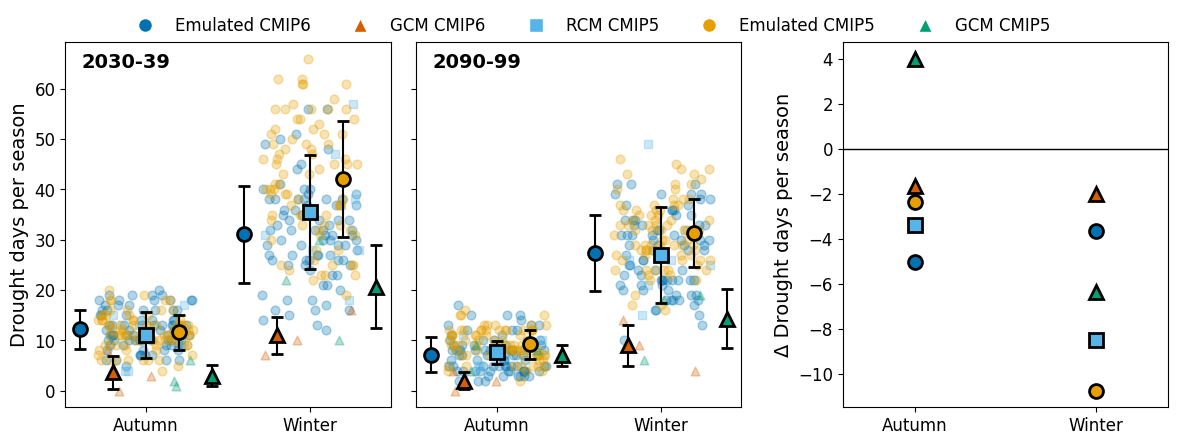

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# --- RNG ---
seed = 42
rng = np.random.default_rng(seed)

# --- File paths ---
emul_past = sorted(
    glob.glob(
        emul_past
    )
)
gcm_past = sorted(
    glob.glob(
        gcm_past
    )
)

emul_future = sorted(
    glob.glob(
        emul_future
    )
)
gcm_future = sorted(
    glob.glob(
        gcm_future
    )
)

rcm_past_id11 = sorted(
    glob.glob(
        rcm_past_id11
    )
)
emul_past_id11 = sorted(
    glob.glob(
        emul_past_id11
    )
)
gcm_past_id11 = sorted(
    glob.glob(gcm_past_id11)
)

rcm_future_id11 = sorted(
    glob.glob(rcm_future_id11)
)
emul_future_id11 = sorted(
    glob.glob(
        emul_future_id11
    )
)
gcm_future_id11 = sorted(
    glob.glob(
        gcm_future_id11
    )
)

# --- Styles ---
styles = {
    "Emulated CMIP6": dict(color="#0072B2", marker="o", alpha=0.3),
    "GCM CMIP6": dict(color="#D55E00", marker="^", alpha=0.3),
    "RCM CMIP5": dict(color="#56B4E9", marker="s", alpha=0.3),
    "Emulated CMIP5": dict(color="#E69F00", marker="o", alpha=0.3),
    "GCM CMIP5": dict(color="#009E73", marker="^", alpha=0.3),
}


# --- Load array (Autumn & Winter only) ---
def load_array_autumn_winter(path, reorder=True):
    arr = np.load(path, allow_pickle=True)
    if isinstance(arr, dict):
        arr = list(arr.values())[0]
    if arr.ndim == 1:
        arr = arr[None, :]
    if reorder:
        arr = arr[:, [1, 2, 0, 3]]  # reorder to Spring, Summer, Autumn, Winter
    return arr[:, [2, 3]]  # select Autumn & Winter


# --- Plot raw points + means ---
def plot_set_ax(ax, sources):
    n_groups = len(sources)
    offsets = np.linspace(-0.4, 0.4, n_groups)

    for offset, (label, files) in zip(offsets, sources.items()):
        if not files:
            continue
        arrays = [load_array_autumn_winter(f) for f in files]
        stack = np.vstack(arrays)
        mean, std = stack.mean(0), stack.std(0)

        # scatter raw points
        for arr in arrays:
            for e in range(arr.shape[0]):
                x = np.arange(arr.shape[1]) + rng.uniform(-0.3, 0.3, size=arr.shape[1])
                y = arr[e, :]
                ax.scatter(
                    x,
                    y,
                    color=styles[label]["color"],
                    marker=styles[label]["marker"],
                    alpha=styles[label]["alpha"],
                    s=40,
                )

        # side-by-side means
        x_vals = np.arange(mean.shape[0]) + offset
        ax.errorbar(
            x_vals,
            mean,
            yerr=std,
            fmt=styles[label]["marker"],
            markeredgecolor="black",
            markeredgewidth=2,
            color=styles[label]["color"],
            ecolor="black",
            markersize=10,
            capsize=4,
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Autumn", "Winter"])


# --- Plot differences ---
def plot_diff_ax(ax, past_sources, future_sources, show_whiskers=True):
    n_groups = len(past_sources)
    offsets = np.linspace(0, 0, n_groups)  # horizontal offsets for each group

    for offset, (label, past_files) in zip(offsets, past_sources.items()):
        future_files = future_sources[label]
        if not past_files or not future_files:
            continue

        past_stack = np.vstack([load_array_autumn_winter(f) for f in past_files])
        future_stack = np.vstack([load_array_autumn_winter(f) for f in future_files])
        mean_diff = future_stack.mean(0) - past_stack.mean(0)
        std_diff = np.sqrt(future_stack.var(0) + past_stack.var(0)) ** 0.5

        x_vals = np.arange(mean_diff.shape[0]) + offset
        yerr = std_diff if show_whiskers else None
        cap = 4 if show_whiskers else 0

        ax.errorbar(
            x_vals,
            mean_diff,
            yerr=yerr,
            fmt=styles[label]["marker"],
            markeredgecolor="black",
            markeredgewidth=2,
            color=styles[label]["color"],
            markersize=10,
            capsize=cap,
            ecolor="black",
            label=label,
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Autumn", "Winter"])
    ax.axhline(0, color="k", lw=1)
    ax.set_xlim(-0.4, 1.4)


# --- Sources ---
sources_past = {
    "Emulated CMIP6": emul_past,
    "GCM CMIP6": gcm_past,
    "RCM CMIP5": rcm_past_id11,
    "Emulated CMIP5": emul_past_id11,
    "GCM CMIP5": gcm_past_id11,
}
sources_future = {
    "Emulated CMIP6": emul_future,
    "GCM CMIP6": gcm_future,
    "RCM CMIP5": rcm_future_id11,
    "Emulated CMIP5": emul_future_id11,
    "GCM CMIP5": gcm_future_id11,
}

# --- Figure ---
fig = plt.figure(figsize=(12, 4.5))
gs = gridspec.GridSpec(1, 4, width_ratios=[1.3, 1.3, 0.2, 1.3])

# Plot 1: Past
ax1 = fig.add_subplot(gs[0])
plot_set_ax(ax1, sources_past)
ax1.set_ylabel("Drought days per season")
ax1.text(
    0.05,
    0.97,
    "2030-39",
    transform=ax1.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
)

# Plot 2: Future
ax2 = fig.add_subplot(gs[1], sharey=ax1)
plot_set_ax(ax2, sources_future)
plt.setp(ax2.get_yticklabels(), visible=False)
ax2.text(
    0.05,
    0.97,
    "2090-99",
    transform=ax2.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
)

# Plot 3: Difference
ax3 = fig.add_subplot(gs[3])
plot_diff_ax(ax3, sources_past, sources_future, show_whiskers=False)
ax3.set_ylabel("Δ Drought days per season")

# Legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker=v["marker"],
        color="w",
        markerfacecolor=v["color"],
        label=k,
        markersize=10,
    )
    for k, v in styles.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=5,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(top=0.92, wspace=0.1)
plt.savefig("../plots/0074_diff_autumn_winter.pdf")
plt.show()